# Study of Recurrent Neural Network (RNN)

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
print(f'Import PyTorch V{torch.__version__}')

dev = torch.device(type='cuda') if torch.cuda.is_available() else \
      torch.device(type='cpu')
print(f'Use device {dev}')

Import PyTorch V1.12.1
Use device cpu


In [3]:
from d2l import torch as d2l
d2l.use_svg_display()

## Working with sequences

In [5]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2

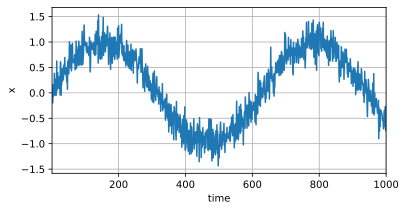

In [7]:
data = Data()
d2l.plot(data.time, data.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [8]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i : self.T-self.tau+i] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

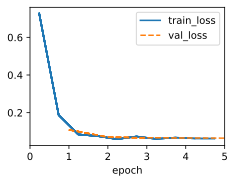

In [9]:
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

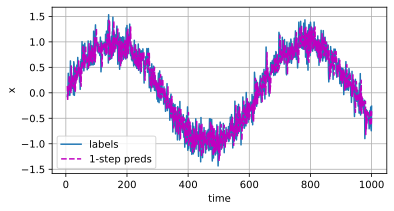

In [10]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

## Converting Raw Text into Sequence Data

In [11]:
import collections
import random
import re

In [12]:
class TimeMachine(d2l.DataModule): #@save
    """The Time Machine dataset."""
    def _download(self):
        fname = d2l.download(d2l.DATA_URL + 'timemachine.txt', self.root,
                             '090b5e7e70c295757f55df93cb0a180b9691891a')
        with open(fname) as f:
            return f.read()

In [13]:
print('Prepare time machine text material')
data = TimeMachine()
raw_text = data._download()
raw_text[:60]

Prepare time machine text material


'The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra'